In [1]:
import pandas as pd

df_pats = pd.read_csv("imputation_results_by_patient_test.csv")
print("Registros:", len(df_pats))

Registros: 10


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# Agrupamentos
# ======================
df_grouped = (
    df_pats
    .groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse']
    .mean()
    .reset_index()
)

df_memory = (
    df_pats
    .groupby(['mechanism', 'patient', 'imputer'])['memory']
    .mean()
    .reset_index()
)

# ======================
# Ordens
# ======================
order_mec = ['S1', 'S2', 'S3', 'S4']
order_imputers = [
    'mean',
    'tree-ad_dd_DummyDriftDetector',
    'tree-ad_dd_ADWIN',
    'tree-ad_dd_KSWIN',
    'tree-ad_dd_PageHinkley'
]

# ======================
# Labels bonitos dos imputers
# ======================
new_labels = {
    'mean': 'Mean',
    'tree-ad_dd_ADWIN': 'ADWIN',
    'tree-ad_dd_KSWIN': 'KSWIN',
    'tree-ad_dd_DummyDriftDetector': 'Dummy',
    'tree-ad_dd_PageHinkley': 'PH',
}
pretty_imputers = [new_labels[i] for i in order_imputers]

# ======================
# Labels LaTeX dos mechanisms
# ======================
mec_labels = {}
for mec in order_mec:
    mec_labels[mec] = f"$S_{{{mec[1]}}}$"

df_grouped['mechanism_label'] = df_grouped['mechanism'].map(mec_labels)
df_memory['mechanism_label'] = df_memory['mechanism'].map(mec_labels)

pal = sns.light_palette("purple", n_colors=7)
pal = pal[1:7]

print(mec_labels)


{'S1': '$S_{1}$', 'S2': '$S_{2}$', 'S3': '$S_{3}$', 'S4': '$S_{4}$'}


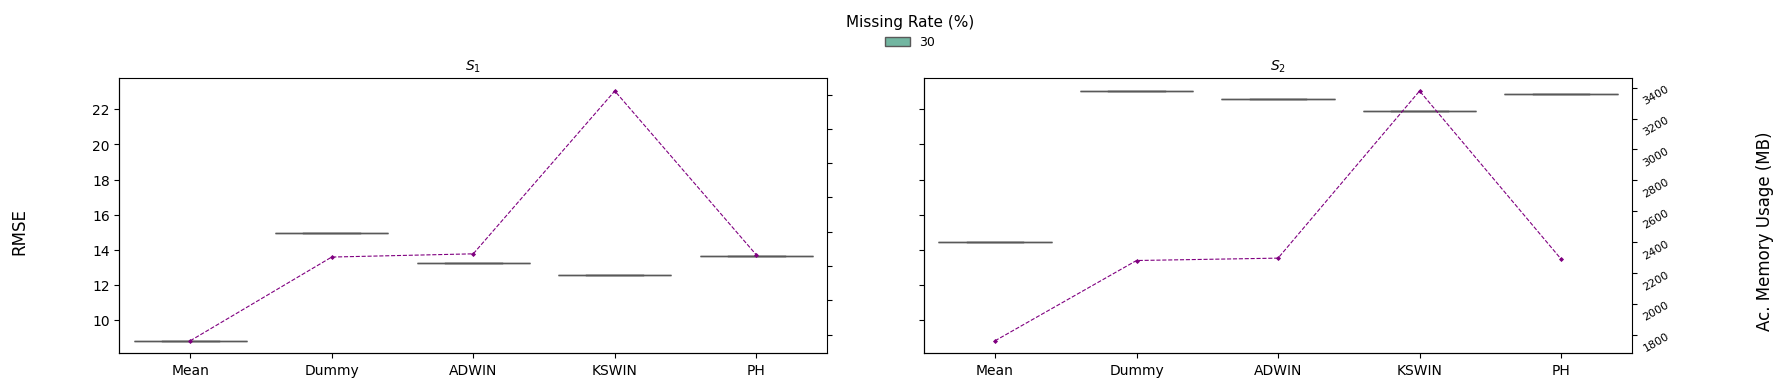

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================
# Layout
# ======================
order_mec = ["S1", "S2", "S3", "S4"]

g = sns.catplot(
    data=df_grouped,
    x="imputer",
    y="mean_rmse",
    hue="missing_rate",
    col="mechanism_label",
    order=order_imputers,
    kind="box",
    palette="Set2",
    width=0.8,
    height=3,
    aspect=1.7,
    flierprops=dict(
        marker="o",
        markersize=3,
        markeredgewidth=0.2,
        markeredgecolor="black",
    ),
)

axes = g.axes.flatten()
ncols = 4

# ======================
# Segundo eixo (Memória)
# ======================
for i, (ax, mechanism) in enumerate(zip(axes, order_mec)):

    ax2 = ax.twinx()

    sns.pointplot(
        data=df_memory[df_memory['mechanism'] == mechanism],
        x='imputer',
        y='memory',
        color='purple',
        markers='D',
        linestyles='--',
        linewidth=0.8,
        ax=ax2,
    )

    col = i % ncols

    # ----------------------
    # Eixo Y esquerdo → apenas primeira coluna
    # ----------------------
    if col == 0:
        ax.tick_params(axis='y', labelleft=True)
    else:
        ax.tick_params(axis='y', labelleft=False)

    ax.set_ylabel("")

    # ----------------------
    # Eixo Y direito → apenas última coluna
    # ----------------------
    if col == ncols - 1 or i == len(axes) - 1:
        ax2.tick_params(axis='y',
                        labelright=True,
                        labelrotation=30,
                        labelsize=8)
    else:
        ax2.tick_params(axis='y', labelright=False)

    ax2.set_ylabel("")

# ======================
# Legenda superior
# ======================
handles = g._legend_data.values()
labels = g._legend_data.keys()
g._legend.remove()

g.figure.legend(
    handles,
    labels,
    title="Missing Rate (%)",
    loc='upper center',
    ncol=len(labels),
    frameon=False,
    bbox_to_anchor=(0.5, 1.07),
    fontsize=9,
    title_fontsize=11
)

g.set_titles(col_template="{col_name}")
g.set_xlabels("")

for ax in axes:
    ax.set_xticks(range(len(order_imputers)))
    ax.set_xticklabels(pretty_imputers, rotation=0)
    ax.tick_params(axis='x', labelbottom=True)


plt.draw()  


g.figure.text(
    0.0, 0.5,
    "RMSE",
    va='center',
    rotation='vertical',
    fontsize=12
)

g.figure.text(
    0.97, 0.5,
    "Ac. Memory Usage (MB)",
    va='center',
    rotation='vertical',
    fontsize=12
)

g.figure.set_size_inches(18, 4)


# plt.savefig(
#     "Plots/boxplot_imputers_box.png",
#     bbox_inches='tight',
#     dpi=300
# )

plt.show()

CD-Diagrams

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cd_diagram import draw_cd_diagram

In [4]:
# df = pd.read_csv("Imp_Results/imputation_results_by_patient.csv")
# df_pats = df_pats[df_pats["mean_rmse"] < 100]

new_labels = {
    'mean': 'Mean',
    'tree-ad_dd_ADWIN': 'ADWIN',
    'tree-ad_dd_KSWIN': 'KSWIN',
    'tree-ad_dd_DummyDriftDetector': 'Dummy',
    'tree-ad_dd_PageHinkley': 'PH',
}

df_pats['imputer'] = df_pats['imputer'].map(new_labels)

mechanisms = df_pats['mechanism'].unique()

mec_labels = {}
for mec in order_mec:
    mec_labels[mec] = f"$S_{{{mec[1]}}}$"

df_crit= df_pats.groupby(['mechanism', 'patient', 'missing_rate', 'imputer'])['mean_rmse'].mean().reset_index()
df_crit['dataset_name'] = df_crit['mechanism'] + '_' + df_crit['patient'] + '_' + df_crit['missing_rate'].astype(str)
df_crit = df_crit.rename(columns={'imputer': 'classifier_name'})
df_crit = df_crit.rename(columns={'mean_rmse': 'accuracy'})
df_crit['accuracy'] = df_crit['accuracy'] * -1
df_crit = df_crit.drop(columns=['patient', 'missing_rate'])
df_crit = df_crit[['classifier_name', 'dataset_name', 'accuracy', 'mechanism']]

df_crit

,classifier_name,dataset_name,accuracy,mechanism
0,ADWIN,S1_A0NVTRV_30,-13.25,S1
1,Dummy,S1_A0NVTRV_30,-14.93,S1
2,KSWIN,S1_A0NVTRV_30,-12.56,S1
3,Mean,S1_A0NVTRV_30,-8.81,S1
4,PH,S1_A0NVTRV_30,-13.63,S1
5,ADWIN,S2_A0NVTRV_30,-22.58,S2
6,Dummy,S2_A0NVTRV_30,-23.05,S2
7,KSWIN,S2_A0NVTRV_30,-21.92,S2
8,Mean,S2_A0NVTRV_30,-14.44,S2
9,PH,S2_A0NVTRV_30,-22.86,S2


In [5]:
dfs = {}

for mec in df_crit['mechanism'].unique():
    dfs[mec] = df_crit[df_crit['mechanism'] == mec].drop(columns=['mechanism'])

for mec, df_mec in dfs.items():
    draw_cd_diagram(df_perf=df_mec, title=f"{mec_labels[mec]}", labels=False, save_path=f"Plots/CD_Diagrams/CD-{mec}.png")

['ADWIN' 'Dummy' 'KSWIN' 'Mean' 'PH']
the null hypothesis over the entire classifiers cannot be rejected


NameError: name 'exit' is not defined

In [17]:
from PIL import Image

# List of CD diagram images in order
image_files = [f"Plots/CD_Diagrams/CD-{mec}.png" for mec in mechanisms]

# Open all images
images = [Image.open(img_file) for img_file in image_files]

# Get dimensions
widths, heights = zip(*(img.size for img in images))

# Calculate total height and max width
total_height = sum(heights)
max_width = max(widths)

# Create new image with combined height
combined_image = Image.new('RGB', (max_width, total_height), 'white')

# Paste images one below the other
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.size[1]

# Save combined image
combined_image.save('Plots/CD_Diagrams/CD-all-mechanisms.png')
print("Combined image saved as CD-all-mechanisms.png")

FileNotFoundError: [Errno 2] No such file or directory: 'Plots/CD_Diagrams/CD-S1.png'